In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import glob
from tqdm.auto import tqdm
import numpy as np
import os
import json

from semantic_state_estimator.constants import (
    RENDERS_DIR,
    TRUE_STATES_DIR,
    PROCESSED_DIR,
)

def load_all(data_dir):
    seeds = os.listdir(os.path.join(data_dir, PROCESSED_DIR))

    all_renders = {}
    gts = {}
    preds = {seed: {} for seed in seeds}
    for renders_file in tqdm(glob.glob(os.path.join(data_dir, RENDERS_DIR, '*.npz'))):
        dp_name = os.path.splitext(os.path.basename(renders_file))[0]

        with np.load(renders_file) as data:
            all_renders[dp_name] = {k: data[k] for k in data}
        
        gt_path = os.path.join(data_dir, TRUE_STATES_DIR, dp_name + '.json')
        if os.path.exists(gt_path):
            with open(gt_path, 'r') as f:
                gts[dp_name] = json.load(f)
    
        for seed in seeds:
            pred_path = os.path.join(data_dir, PROCESSED_DIR, str(seed), dp_name + '.json')
            if os.path.exists(pred_path):
                with open(pred_path, 'r') as f:
                    preds[seed][dp_name] = json.load(f)
                first_item = next(iter(preds[seed][dp_name].values()))
                if isinstance(first_item, dict):
                    means = defaultdict(int)
                    num_viewpoints = len(preds[seed][dp_name])
                    for k, v in  preds[seed][dp_name].items():
                        preds.setdefault(seed + ' ' + k, {})[dp_name] = v
                        for predicate, score in v.items():
                            means[predicate] += score / num_viewpoints
                    preds[seed][dp_name] = means

    return all_renders, gts, preds

all_renders, gts, preds = load_all('examples/prb/data_dir')

  0%|          | 0/7599 [00:00<?, ?it/s]

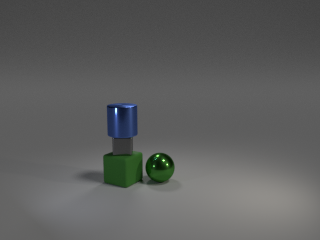

is-directly-on-table(large-green-metal-sphere)
is-directly-on-table(large-green-rubber-cube)
is-clear-on-top(large-green-metal-sphere)
is-clear-on-top(large-blue-metal-cylinder)
block-on-top-of-block(small-grey-metal-cube,large-green-rubber-cube)
block-on-top-of-block(large-blue-metal-cylinder,small-grey-metal-cube)


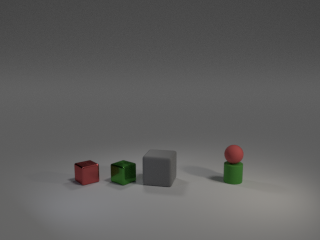

is-directly-on-table(large-grey-rubber-cube)
is-directly-on-table(small-red-metal-cube)
is-directly-on-table(small-green-metal-cube)
is-directly-on-table(small-green-rubber-cylinder)
is-clear-on-top(large-grey-rubber-cube)
is-clear-on-top(small-red-metal-cube)
is-clear-on-top(small-green-metal-cube)
is-clear-on-top(small-red-rubber-sphere)
block-on-top-of-block(small-red-rubber-sphere,small-green-rubber-cylinder)


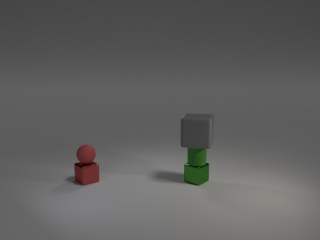

is-directly-on-table(small-red-metal-cube)
is-directly-on-table(small-green-metal-cube)
is-clear-on-top(large-grey-rubber-cube)
is-clear-on-top(small-red-rubber-sphere)
block-on-top-of-block(small-red-rubber-sphere,small-red-metal-cube)
block-on-top-of-block(small-green-rubber-cylinder,small-green-metal-cube)
block-on-top-of-block(large-grey-rubber-cube,small-green-rubber-cylinder)


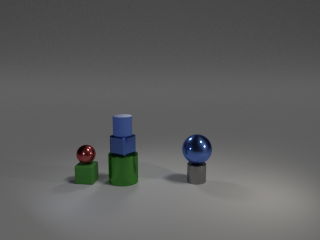

is-directly-on-table(large-green-metal-cylinder)
is-directly-on-table(small-grey-metal-cylinder)
is-directly-on-table(small-green-rubber-cube)
is-clear-on-top(small-blue-rubber-cylinder)
is-clear-on-top(small-red-metal-sphere)
is-clear-on-top(large-blue-metal-sphere)
block-on-top-of-block(small-blue-rubber-cylinder,small-blue-metal-cube)
block-on-top-of-block(small-blue-metal-cube,large-green-metal-cylinder)
block-on-top-of-block(large-blue-metal-sphere,small-grey-metal-cylinder)
block-on-top-of-block(small-red-metal-sphere,small-green-rubber-cube)


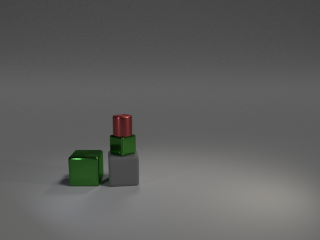

is-directly-on-table(large-grey-rubber-cube)
is-directly-on-table(large-green-metal-cube)
is-clear-on-top(large-green-metal-cube)
is-clear-on-top(small-red-metal-cylinder)
block-on-top-of-block(small-green-metal-cube,large-grey-rubber-cube)
block-on-top-of-block(small-red-metal-cylinder,small-green-metal-cube)


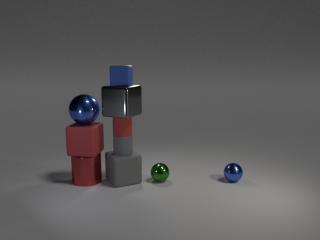

is-directly-on-table(large-red-metal-cylinder)
is-directly-on-table(small-blue-metal-sphere)
is-directly-on-table(small-green-metal-sphere)
is-directly-on-table(large-grey-rubber-cube)
is-clear-on-top(small-blue-metal-sphere)
is-clear-on-top(small-green-metal-sphere)
is-clear-on-top(large-blue-metal-sphere)
is-clear-on-top(small-blue-rubber-cube)
block-on-top-of-block(large-red-rubber-cube,large-red-metal-cylinder)
block-on-top-of-block(large-blue-metal-sphere,large-red-rubber-cube)
block-on-top-of-block(small-blue-rubber-cube,large-grey-metal-cube)
block-on-top-of-block(small-grey-rubber-cylinder,large-grey-rubber-cube)
block-on-top-of-block(small-red-rubber-cylinder,small-grey-rubber-cylinder)
block-on-top-of-block(large-grey-metal-cube,small-red-rubber-cylinder)


In [3]:
from PIL import Image

dps = list(gts.keys())

for _ in range(6):
    dp_name = np.random.choice(dps)
    for k, img_arr in all_renders[dp_name].items():
        img = Image.fromarray(img_arr)
        display(img)
        for predicate, value in gts[dp_name].items():
            if value:
                print(predicate)

In [4]:
from collections import defaultdict
from functools import reduce

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    recall_score
)
import numpy as np


from semantic_state_estimator.utils.statistics import acc_curve
from semantic_state_estimator.utils.misc import squash_predicate


def collect_metrics(ground_truths, predicted_scores):
    per_pred_values = defaultdict(list)
    for dp, scores in predicted_scores.items():
        for predicate, pred_score in scores.items():
            per_pred_values[predicate].append((pred_score, ground_truths[dp][predicate]))
    

    # instantiate output containters
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}

    # iterate predicates
    for pred, pred_values in tqdm(per_pred_values.items(), desc='iterating predicates'):
        y_score, y = map(np.array, zip(*pred_values))
        accuracy[pred], _ = acc_curve(y, y_score, num_thresholds=100)

        if np.all(~y):
            continue  # skip precision-recall and AP if no positive label examples exist
        precision[pred], recall[pred], thresholds[pred] = precision_recall_curve(y, y_score)
        thresholds[pred] = np.concatenate([thresholds[pred], [1]])  # last threshold is omitted. add it back
        average_precision[pred] = average_precision_score(y, y_score)

    accuracy['average'] = [sum([acc_lst[t] for acc_lst in accuracy.values()]) / len(per_pred_values) for t in range(101)]
    average_precision['macro average'] = np.mean(list(average_precision.values()))
    
    flat_y_score, flat_y = map(np.array, zip(*list(reduce(lambda x, y: x + y, per_pred_values.values()))))
    average_precision['micro average'] = average_precision_score(flat_y, flat_y_score, average='micro')

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
    )

def collect_metrics_all_models(ground_truths, predicted_scores_all_models):
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}
    
    for model, predicted_scores in tqdm(predicted_scores_all_models.items()):
        (
            accuracy[model],
            precision[model],
            recall[model],
            thresholds[model],
            average_precision[model],
        ) = collect_metrics(ground_truths, predicted_scores)

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
    )

In [ ]:
import warnings
warnings.filterwarnings("ignore")

(
    accuracy,
    precision,
    recall,
    thresholds,
    average_precision,
) = collect_metrics_all_models(gts, preds)

  0%|          | 0/4 [00:00<?, ?it/s]

iterating predicates:   0%|          | 0/2304 [00:00<?, ?it/s]

iterating predicates:   0%|          | 0/2304 [00:00<?, ?it/s]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

sns.set_theme()
colors = list(sns.color_palette())

displayed_models = ['0.5B',
                    '7B',
                    '72B']

color_map = dict(zip(displayed_models, colors))

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
from functools import partial
from itertools import product
import sys
sys.path.append('./examples/prb')

from semantic_state_estimator.constants import SCENES_DIR
from prb_env import NewState

def get_state(data_dir, dp_name):
    with open(os.path.join(data_dir, SCENES_DIR, dp_name + '.json')) as f:
        data = json.load(f)
    return NewState.undump(data)

def filter_single_material_only(mat, data_dir, dp_name):
    state = get_state(data_dir, dp_name)
    return all(o.mat_name == mat for o in state.objects)

def filter_no_color_repeat(data_dir, dp_name):
    state = get_state(data_dir, dp_name)
    return all(o1 is o2 or o1.color != o2.color for o1, o2 in product(state.objects, state.objects))

def filter_no_color_same_size_repeat(data_dir, dp_name):
    state = get_state(data_dir, dp_name)
    return all(o1 is o2 or o1.size_name != o2.size_name or o1.color != o2.color for o1, o2 in product(state.objects, state.objects))

def filter_no_color_smae_shape_repeat(data_dir, dp_name):
    state = get_state(data_dir, dp_name)
    return all(o1 is o2 or o1.shape_name != o2.shape_name or o1.color != o2.color for o1, o2 in product(state.objects, state.objects))

def filter_up_to_n_objects(n, data_dir, dp_name):
    state = get_state(data_dir, dp_name)
    return len(state.objects) <= n

def filter_data(all_renders, gts, preds, data_dir, filter_fn):
    filter_fn = partial(filter_fn, data_dir)
    filtered_dps = set(filter(filter_fn, tqdm(all_renders.keys(), desc='filtering dps')))

    new_renders = {dp_name: all_renders[dp_name] for dp_name in tqdm(filtered_dps, desc='collecting renders')}
    new_gts = {dp_name: gt for dp_name, gt in tqdm(gts.items(), desc='collecting gt') if dp_name in filtered_dps}
    new_preds = {
        model: {
            dp_name: pred
            for dp_name, pred in tqdm(model_preds.items(), desc=f'collecting preds for model {model}')
            if dp_name in filtered_dps
        }
        for model, model_preds in preds.items()
    }

    print('num data points filtered:', len(new_gts))

    return new_renders, new_gts, new_preds

In [ ]:
all_renders_rubber, gts_rubber, preds_rubber = filter_data(all_renders, gts, preds,
                                                           'examples/prb/data_dir',
                                                           filter_fn=partial(filter_single_material_only, 'rubber'))


In [ ]:
(
    accuracy_rubber,
    precision_rubber,
    recall_rubber,
    thresholds_rubber,
    average_precision_rubber,
) = collect_metrics_all_models(gts_rubber, preds_rubber)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_rubber.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_rubber.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_rubber.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_rubber.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_rubber.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
all_renders_metal, gts_metal, preds_metal = filter_data(all_renders, gts, preds,
                                                        'examples/prb/data_dir',
                                                        filter_fn=partial(filter_single_material_only, 'metal'))

In [ ]:
(
    accuracy_metal,
    precision_metal,
    recall_metal,
    thresholds_metal,
    average_precision_metal,
) = collect_metrics_all_models(gts_metal, preds_metal)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_metal.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_metal.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_metal.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_metal.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_metal.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
all_renders_color, gts_color, preds_color = filter_data(all_renders, gts, preds,
                                                        'examples/prb/data_dir',
                                                        filter_fn=filter_no_color_repeat)

In [ ]:
(
    accuracy_color,
    precision_color,
    recall_color,
    thresholds_color,
    average_precision_color,
) = collect_metrics_all_models(gts_color, preds_color)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_color.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_color.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_color.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_color.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_color.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
all_renders_color_size, gts_color_size, preds_color_size = filter_data(all_renders, gts, preds,
                                                        'examples/prb/data_dir',
                                                        filter_fn=filter_no_color_same_size_repeat)

In [ ]:
(
    accuracy_color_size,
    precision_color_size,
    recall_color_size,
    thresholds_color_size,
    average_precision_color_size,
) = collect_metrics_all_models(gts_color_size, preds_color_size)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_color_size.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_color_size.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_color_size.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_color_size.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_color_size.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
all_renders_color_shape, gts_color_shape, preds_color_shape = filter_data(all_renders, gts, preds,
                                                        'examples/prb/data_dir',
                                                        filter_fn=filter_no_color_smae_shape_repeat)

In [ ]:
(
    accuracy_color_shape,
    precision_color_shape,
    recall_color_shape,
    thresholds_color_shape,
    average_precision_color_shape,
) = collect_metrics_all_models(gts_color_shape, preds_color_shape)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_color_shape.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_color_shape.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_color_shape.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_color_shape.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_color_shape.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
all_renders_3, gts_3, preds_3 = filter_data(all_renders, gts, preds,
                                            'examples/prb/data_dir',
                                            filter_fn=partial(filter_up_to_n_objects, 3))

In [ ]:
(
    accuracy_3,
    precision_3,
    recall_3,
    thresholds_3,
    average_precision_3,
) = collect_metrics_all_models(gts_3, preds_3)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_3.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_3.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_3.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_3.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_3.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
all_renders_5, gts_5, preds_5 = filter_data(all_renders, gts, preds,
                                            'examples/prb/data_dir',
                                            filter_fn=partial(filter_up_to_n_objects, 5))

In [ ]:
(
    accuracy_5,
    precision_5,
    recall_5,
    thresholds_5,
    average_precision_5,
) = collect_metrics_all_models(gts_5, preds_5)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_5.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_5.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_5.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_5.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_5.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
all_renders_7, gts_7, preds_7 = filter_data(all_renders, gts, preds,
                                            'examples/prb/data_dir',
                                            filter_fn=partial(filter_up_to_n_objects, 7))

In [ ]:
(
    accuracy_7,
    precision_7,
    recall_7,
    thresholds_7,
    average_precision_7,
) = collect_metrics_all_models(gts_7, preds_7)

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_7.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_7.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_7.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_7.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_7.items()},
}).T[['0.5B', '7B', '72B']]

table.T

In [ ]:
from natsort import natsort_keygen

table_3 = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_3.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_3.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_3.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_3.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_3.items()},
}).T[['0.5B', '7B', '72B']].T
table_3.rename(index={'0.5B': '0.5B ($\le 3$)', '7B':'7B ($\le 3$)', '72B': '72B ($\le 3$)'}, inplace=True)

table_5 = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_5.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_5.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_5.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_5.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_5.items()},
}).T[['0.5B', '7B', '72B']].T
table_5.rename(index={'0.5B': '0.5B ($\le 5$)', '7B':'7B ($\le 5$)', '72B': '72B ($\le 5$)'}, inplace=True)

table_7 = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_7.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_7.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_7.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_7.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_7.items()},
}).T[['0.5B', '7B', '72B']].T
table_7.rename(index={'0.5B': '0.5B ($\le 7$)', '7B':'7B ($\le 7$)', '72B': '72B ($\le 7$)'}, inplace=True)

table_10 = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision.items()},
}).T[['0.5B', '7B', '72B']].T
table_10.rename(index={'0.5B': '0.5B ($\le 10$)', '7B':'7B ($\le 10$)', '72B': '72B ($\le 10$)'}, inplace=True)

table_num_objs = pd.concat([table_3, table_5, table_7, table_10])

table_num_objs = table_num_objs.sort_index(key=natsort_keygen())
table_num_objs

In [ ]:
print(table_num_objs.to_latex(float_format="%.2f"))

In [ ]:
table_rubber = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_rubber.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_rubber.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_rubber.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_rubber.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_rubber.items()},
}).T[['0.5B', '7B', '72B']].T
table_rubber.rename(index={'0.5B': '0.5B (rubber only)', '7B': '7B (rubber only)', '72B': '72B (rubber only)'}, inplace=True)

table_metal = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_metal.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_metal.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_metal.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_metal.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_metal.items()},
}).T[['0.5B', '7B', '72B']].T
table_metal.rename(index={'0.5B': '0.5B (metal only)', '7B': '7B (metal only)', '72B': '72B (metal only)'}, inplace=True)

table_color = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_color.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_color.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_color.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_color.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_color.items()},
}).T[['0.5B', '7B', '72B']].T
table_color.rename(index={'0.5B': '0.5B (color conflict)', '7B': '7B (color conflict)', '72B': '72B (color conflict)'}, inplace=True)

table_color_size = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_color_size.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_color_size.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_color_size.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_color_size.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_color_size.items()},
}).T[['0.5B', '7B', '72B']].T
table_color_size.rename(index={'0.5B': '0.5B (color-size conflict)', '7B': '7B (color-size conflict)', '72B': '72B (color-size conflict)'}, inplace=True)

table_color_shape = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy_color_shape.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy_color_shape.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy_color_shape.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision_color_shape.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision_color_shape.items()},
}).T[['0.5B', '7B', '72B']].T
table_color_shape.rename(index={'0.5B': '0.5B (color-shape conflict)', '7B': '7B (color-shape conflict)', '72B': '72B (color-shape conflict)'}, inplace=True)

table_unduplicates = pd.concat([table_rubber, table_metal, table_color, table_color_size, table_color_shape])

def idx_sorter(index):
    out = []
    for idx in index:
        out.append(float(idx.split('B')[0]))
    return pd.Index(out)

table_unduplicates = table_unduplicates.sort_index(key=idx_sorter)
table_unduplicates

In [ ]:
print(table_unduplicates.to_latex(float_format="%.2f").replace('\t', '\\t'))